# 04 — Results Analysis

Statistical analysis of the data efficiency experiment results:

- Model ranking table (best fraction → best AUROC)
- DeLong pairwise statistical test on full-dataset results
- ROC curves per model at 100% training data
- Confusion matrix inspection (MES)
- Per-class sensitivity analysis (MES)

Run **after** completing the experiments and reviewing notebooks 01–03.

In [85]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve

from src.evaluation import plot_delong_heatmap
from src.evaluation.delong import delong_matrix
from src.evaluation.plots import plot_roc_curves

ROOT = Path("..")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## Configuration

In [86]:
ULCER_RESULTS = ROOT / "results/ulcer/data_efficiency/results.csv"
ULCER_RAW     = ROOT / "results/ulcer/data_efficiency/results_per_seed.csv"
ULCER_PREDS   = ROOT / "results/ulcer/data_efficiency/predictions"

MES_RESULTS   = ROOT / "results/mes/data_efficiency/results.csv"
MES_RAW       = ROOT / "results/mes/data_efficiency/results_per_seed.csv"
MES_PREDS     = ROOT / "results/mes/data_efficiency/predictions"

# Significance threshold for DeLong test
ALPHA = 0.05

## 1. Load Results

In [87]:
def load_df(path, label):
    if not path.exists():
        print(f"[{label}] Not found: {path}")
        return None
    return pd.read_csv(path)

df_ulcer = load_df(ULCER_RESULTS, "ULCER")
df_mes   = load_df(MES_RESULTS,   "MES")
raw_ulcer = load_df(ULCER_RAW, "ULCER-RAW")
raw_mes   = load_df(MES_RAW,   "MES-RAW")

## 2. Model Ranking Table

In [88]:
def ranking_table(df: pd.DataFrame, task: str, metric: str = "auroc_mean") -> None:
    if df is None:
        return

    best = df.sort_values(metric, ascending=False)

    display_cols = [c for c in [
        "model", "freeze", "head_type", "pct_data", "seed",
        "_best_shared_seed",
        "auroc_mean", "auroc_std", "f1_mean", "f1_std",
        "tuned_sensitivity_mean", "tuned_specificity_mean",
        "tuned_f1_mean", "tuned_f1_std", "clip_auroc_mean",
        "auroc", "f1", "tuned_f1", "tuned_sensitivity", "tuned_specificity", "clip_auroc",
    ] if c in best.columns]

    avg_note = "values = mean over seeds" if "mean" in metric else "single seed"
    print(f"\n{'='*60}\n{task} — model ranking [{avg_note}]\n{'='*60}")
    display(best[display_cols].reset_index(drop=True).round(4).head(10))

ranking_table(df_ulcer, "Ulcer detection")
ranking_table(df_mes,   "MES scoring")


Ulcer detection — model ranking [values = mean over seeds]


,model,freeze,head_type,pct_data,auroc_mean,auroc_std,f1_mean,f1_std,tuned_sensitivity_mean,tuned_specificity_mean,tuned_f1_mean,tuned_f1_std,clip_auroc_mean
0,efficientnetb0,finetune,linear,100,0.9298,0.0102,0.7040,0.0411,0.8581,0.8417,0.6963,0.0213,0.9392
1,efficientnetb0,finetune,linear,75,0.9253,0.0091,0.6862,0.0513,0.8661,0.8136,0.6713,0.0158,0.9358
2,efficientnetb0,finetune,linear,50,0.9170,0.0222,0.6770,0.0289,0.8639,0.8206,0.6774,0.0315,0.9184
3,vits16_imagenet,finetune,linear,50,0.8900,0.0217,0.6772,0.0616,0.7882,0.8525,0.6700,0.0394,0.8634
4,efficientnetb0,finetune,linear,25,0.8833,0.0434,0.6105,0.0804,0.8239,0.7600,0.6033,0.0585,0.8762
5,vits16_imagenet,finetune,linear,75,0.8812,0.0246,0.6415,0.0485,0.7831,0.8261,0.6402,0.0457,0.8490
6,vits16_imagenet,finetune,linear,25,0.8808,0.0468,0.6290,0.0821,0.7511,0.8468,0.6525,0.0700,0.8605
7,resnet50_1M,finetune,linear,50,0.8783,0.0159,0.6208,0.0537,0.7860,0.7854,0.6065,0.0619,0.8819
8,resnet50_5M,finetune,linear,100,0.8728,0.0175,0.6075,0.0317,0.7409,0.7979,0.5893,0.0548,0.8634
9,resnet50_200K,finetune,linear,100,0.8708,0.0192,0.5968,0.0227,0.7496,0.7821,0.5792,0.0348,0.8466



MES scoring — model ranking [values = mean over seeds]


,model,freeze,head_type,pct_data,auroc_mean,auroc_std,f1_mean,f1_std,clip_auroc_mean
0,resnet50_200K,finetune,linear,50,0.7200,0.0143,0.4187,0.0148,0.7663
1,resnet50_5M,finetune,linear,100,0.6912,0.0236,0.3635,0.0643,0.7272
2,vits16_gastronet,finetune,linear,50,0.6905,0.0283,0.3823,0.0437,0.7173
3,resnet50_5M,finetune,linear,25,0.6902,0.0612,0.3563,0.0579,0.7212
4,resnet50_imagenet,finetune,linear,75,0.6892,0.0246,0.4048,0.0433,0.7227
5,resnet50_5M,finetune,linear,10,0.6840,0.0575,0.3248,0.1099,0.7288
6,resnet50_5M,finetune,linear,50,0.6835,0.0299,0.3612,0.0353,0.7192
7,resnet50_1M,finetune,linear,50,0.6830,0.0316,0.3713,0.0342,0.7193
8,resnet50_200K,finetune,linear,75,0.6812,0.0343,0.3827,0.0364,0.7160
9,resnet50_1M,finetune,linear,100,0.6767,0.0281,0.3577,0.0293,0.7148


In [89]:
ranking_table(raw_ulcer, "Ulcer detection (per-seed)", metric="auroc")
ranking_table(raw_mes,   "MES scoring (per-seed)", metric="auroc")


Ulcer detection (per-seed) — model ranking [single seed]


,model,freeze,head_type,pct_data,seed,auroc,f1,tuned_f1,tuned_sensitivity,tuned_specificity,clip_auroc
0,efficientnetb0,finetune,linear,50,84,0.945,0.711,0.7242,0.9345,0.8316,0.9514
1,efficientnetb0,finetune,linear,100,128,0.938,0.762,0.7351,0.8603,0.8749,0.9514
2,efficientnetb0,finetune,linear,100,84,0.938,0.740,0.6924,0.8603,0.8373,0.9444
3,efficientnetb0,finetune,linear,100,42,0.938,0.715,0.7030,0.8734,0.8407,0.9514
4,efficientnetb0,finetune,linear,75,256,0.934,0.726,0.6579,0.8734,0.7964,0.9549
5,efficientnetb0,finetune,linear,75,128,0.933,0.650,0.6960,0.8646,0.8385,0.9410
6,efficientnetb0,finetune,linear,25,364,0.933,0.713,0.7079,0.8996,0.8328,0.9549
7,efficientnetb0,finetune,linear,75,42,0.929,0.701,0.6646,0.9258,0.7759,0.9479
8,efficientnetb0,finetune,linear,50,128,0.929,0.660,0.7011,0.8603,0.8453,0.9340
9,efficientnetb0,finetune,linear,100,364,0.928,0.668,0.6890,0.8996,0.8146,0.9340



MES scoring (per-seed) — model ranking [single seed]


,model,freeze,head_type,pct_data,seed,auroc,f1,clip_auroc
0,vits16_gastronet,finetune,linear,25,420,0.761,0.453,0.802
1,resnet50_5M,finetune,linear,25,364,0.759,0.425,0.788
2,vits16_gastronet,finetune,linear,10,128,0.756,0.419,0.799
3,resnet50_5M,finetune,linear,10,420,0.750,0.419,0.813
4,vits16_imagenet,finetune,linear,100,420,0.743,0.428,0.790
5,vits16_imagenet,finetune,linear,25,420,0.742,0.453,0.795
6,resnet50_200K,finetune,linear,50,364,0.737,0.426,0.777
7,resnet50_200K,finetune,linear,75,128,0.735,0.442,0.786
8,resnet50_1M,finetune,linear,50,364,0.735,0.421,0.779
9,resnet50_5M,finetune,linear,10,84,0.734,0.447,0.795


## 3. Performance at Each Fraction — Heatmap

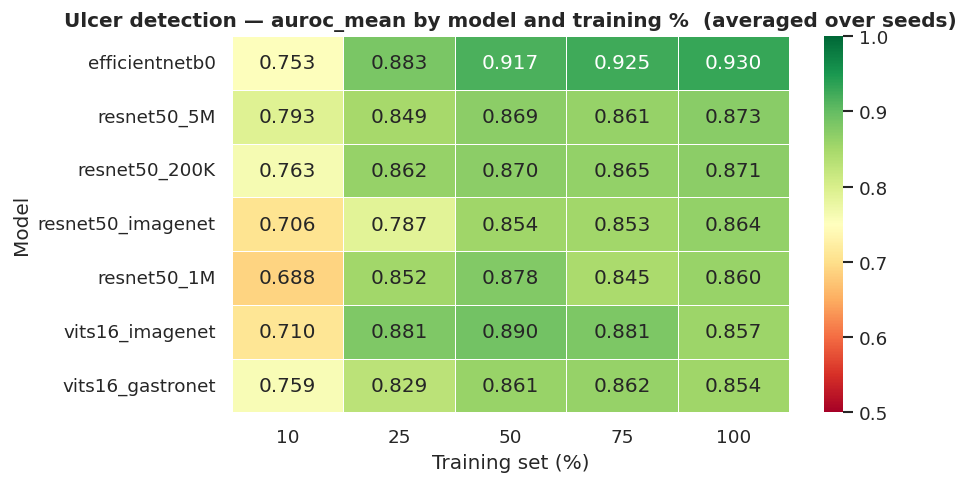

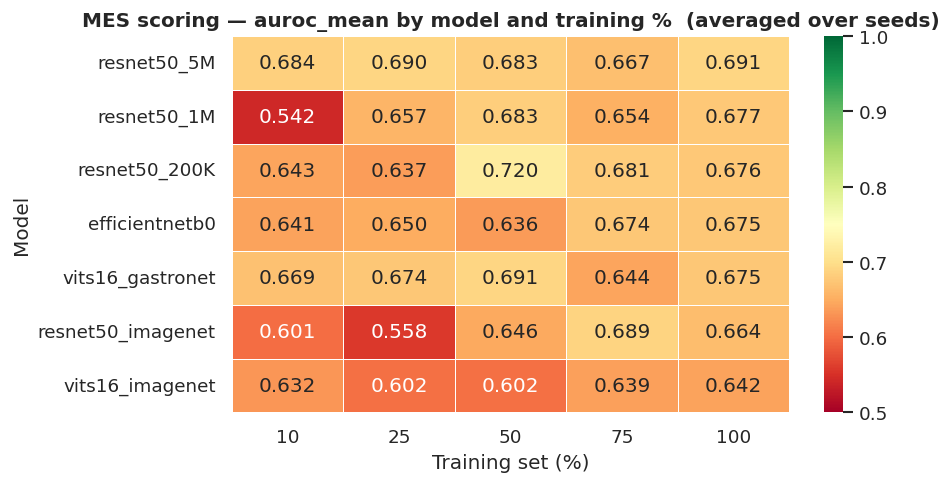

In [90]:
def plot_heatmap(df: pd.DataFrame, task: str, metric: str = "auroc_mean") -> None:
    if df is None or metric not in df.columns:
        return

    pivot = df.pivot_table(index="model", columns="pct_data", values=metric)
    pivot = pivot.sort_values(pivot.columns[-1], ascending=False)

    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 1.2), max(4, len(pivot) * 0.6)))
    sns.heatmap(
        pivot, annot=True, fmt=".3f", cmap="RdYlGn",
        vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5,
    )
    ax.set_title(
        f"{task} — {metric} by model and training %  (averaged over seeds)",
        fontweight="bold",
    )
    ax.set_xlabel("Training set (%)")
    ax.set_ylabel("Model")
    fig.tight_layout()
    plt.show()

plot_heatmap(df_ulcer, "Ulcer detection")
plot_heatmap(df_mes,   "MES scoring")

In [91]:
%matplotlib inline

## 4. DeLong Pairwise Statistical Test

Compares AUROC scores at the **100% training fraction** across all models.
Uses the **single shared seed** that maximises the mean AUROC across all models
(same seed for every model, enabling a fair pairwise comparison on identical test runs).
Requires the saved `.npy` prediction files.

In [92]:
def _best_shared_seed(
    df_raw: pd.DataFrame,
    target_pct: int,
    head_filter: str = "linear",
) -> int | None:
    """Return the seed with the highest mean AUROC across ALL models at target_pct.

    Using a single shared seed keeps test-set predictions comparable: every model
    was trained on the same data split, so differences in performance reflect the
    model, not a lucky/unlucky data split.
    """
    subset = df_raw[
        (df_raw["pct_data"] == target_pct) &
        (df_raw["head_type"] == head_filter)
    ]
    if subset.empty:
        return None
    seed_mean = subset.groupby("seed")["auroc"].mean()
    return int(seed_mean.idxmax())


def load_predictions_at_fraction(
    preds_dir: Path,
    df_raw: pd.DataFrame,
    target_pct: int = 100,
    head_filter: str = "linear",
) -> dict[str, dict]:
    """Load predictions for all models at target_pct using the shared best seed."""
    results = {}
    if df_raw is None or not preds_dir.exists():
        return results

    subset = df_raw[
        (df_raw["pct_data"] == target_pct) &
        (df_raw["head_type"] == head_filter)
    ]

    # Single seed shared across all models
    shared_seed = _best_shared_seed(df_raw, target_pct, head_filter)
    if shared_seed is None:
        print(f"No data found at pct={target_pct}, head={head_filter}.")
        return results
    print(f"Shared seed : {shared_seed}  (best mean AUROC across all models at {target_pct}%)")

    best = subset[subset["seed"] == shared_seed]
    if best.empty:
        print(f"No rows for seed={shared_seed} at {target_pct}%.")
        return results

    for _, row in best.iterrows():
        model_name = row["model"]
        freeze_str = "frozen" if str(row.get("freeze", "finetune")) == "frozen" else "finetune"
        run_name   = (f"{model_name}_{freeze_str}_{row['head_type']}_"
                      f"{target_pct}pct_seed{int(row['seed'])}")
        run_dir      = preds_dir / run_name
        labels_path  = run_dir / "test_labels.npy"
        probs_path   = run_dir / "test_probs.npy"
        if not labels_path.exists() or not probs_path.exists():
            print(f"  [Skip] predictions not found: {run_name}")
            continue
        labels = np.load(labels_path)
        probs  = np.load(probs_path)
        probs_1d = probs.max(axis=1) if probs.ndim == 2 else probs
        # Threshold tuned on the val set during training — stored in results_per_seed.csv
        threshold = float(row["tuned_threshold"]) if "tuned_threshold" in row.index else 0.5
        results[model_name] = {
            "labels":    labels,
            "probs":     probs_1d,
            "probs_all": probs if np.load(probs_path).ndim == 2 else None,
            "auroc":     row["auroc"],
            "seed":      int(row["seed"]),
            "threshold": threshold,
        }
    return results


print("Loading predictions for DeLong test...")
ulcer_preds = load_predictions_at_fraction(ULCER_PREDS, raw_ulcer)
mes_preds   = load_predictions_at_fraction(MES_PREDS,   raw_mes)
print(f"Ulcer models loaded: {list(ulcer_preds.keys())}")
print(f"MES models loaded:   {list(mes_preds.keys())}")

Loading predictions for DeLong test...
Shared seed : 256  (best mean AUROC across all models at 100%)
Shared seed : 420  (best mean AUROC across all models at 100%)
Ulcer models loaded: ['efficientnetb0', 'vits16_imagenet', 'resnet50_imagenet', 'vits16_gastronet', 'resnet50_200K', 'resnet50_1M', 'resnet50_5M']
MES models loaded:   ['efficientnetb0', 'vits16_imagenet', 'resnet50_imagenet', 'vits16_gastronet', 'resnet50_200K', 'resnet50_1M', 'resnet50_5M']



Ulcer detection — DeLong pairwise test (α=0.05)  [100% data, shared seed=256]
          Model A           Model B  AUC A  AUC B    ΔAUC      z  p-value  significant
   efficientnetb0 resnet50_imagenet 0.9241 0.8542  0.0699  6.767   0.0000         True
   efficientnetb0  vits16_gastronet 0.9241 0.8456  0.0785  7.597   0.0000         True
   efficientnetb0     resnet50_200K 0.9241 0.8813  0.0428  5.415   0.0000         True
   efficientnetb0       resnet50_1M 0.9241 0.8678  0.0563  7.766   0.0000         True
  vits16_imagenet resnet50_imagenet 0.9036 0.8542  0.0494  5.157   0.0000         True
   efficientnetb0       resnet50_5M 0.9241 0.8864  0.0378  5.181   0.0000         True
  vits16_imagenet  vits16_gastronet 0.9036 0.8456  0.0580  6.434   0.0000         True
 vits16_gastronet     resnet50_200K 0.8456 0.8813 -0.0357 -5.415   0.0000         True
 vits16_gastronet       resnet50_5M 0.8456 0.8864 -0.0408 -5.911   0.0000         True
  vits16_imagenet       resnet50_1M 0.9036 0.8678  

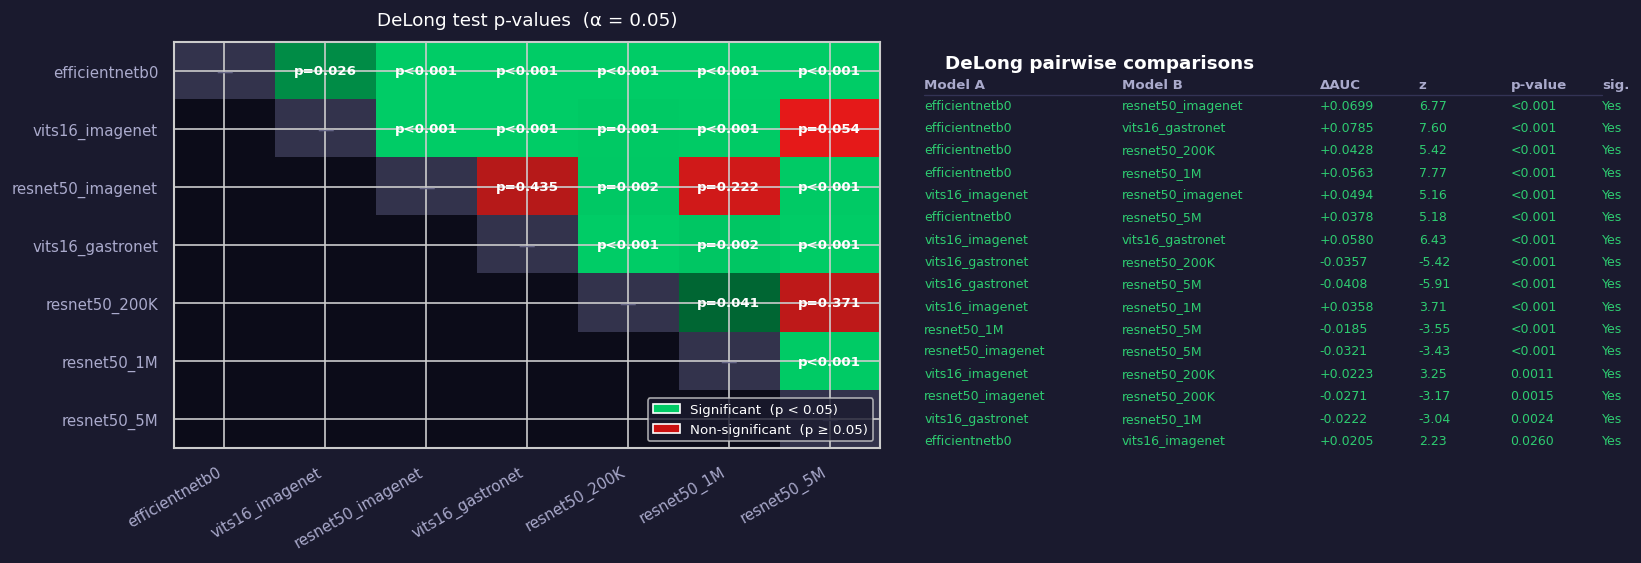


MES scoring — DeLong pairwise test (α=0.05)  [100% data, shared seed=420]
          Model A           Model B  AUC A  AUC B    ΔAUC      z  p-value  significant
  vits16_imagenet  vits16_gastronet 0.5410 0.3459  0.1952  4.436   0.0000         True
resnet50_imagenet  vits16_gastronet 0.5786 0.3459  0.2327  5.216   0.0000         True
 vits16_gastronet     resnet50_200K 0.3459 0.5096 -0.1637 -3.853   0.0001         True
resnet50_imagenet       resnet50_5M 0.5786 0.4289  0.1497  3.503   0.0005         True
resnet50_imagenet       resnet50_1M 0.5786 0.4453  0.1332  3.237   0.0012         True
   efficientnetb0 resnet50_imagenet 0.4668 0.5786 -0.1118 -2.799   0.0051         True
   efficientnetb0  vits16_gastronet 0.4668 0.3459  0.1209  2.705   0.0068         True
  vits16_imagenet       resnet50_5M 0.5410 0.4289  0.1122  2.558   0.0105         True
  vits16_imagenet       resnet50_1M 0.5410 0.4453  0.0957  2.332   0.0197         True
 vits16_gastronet       resnet50_1M 0.3459 0.4453 -0.09

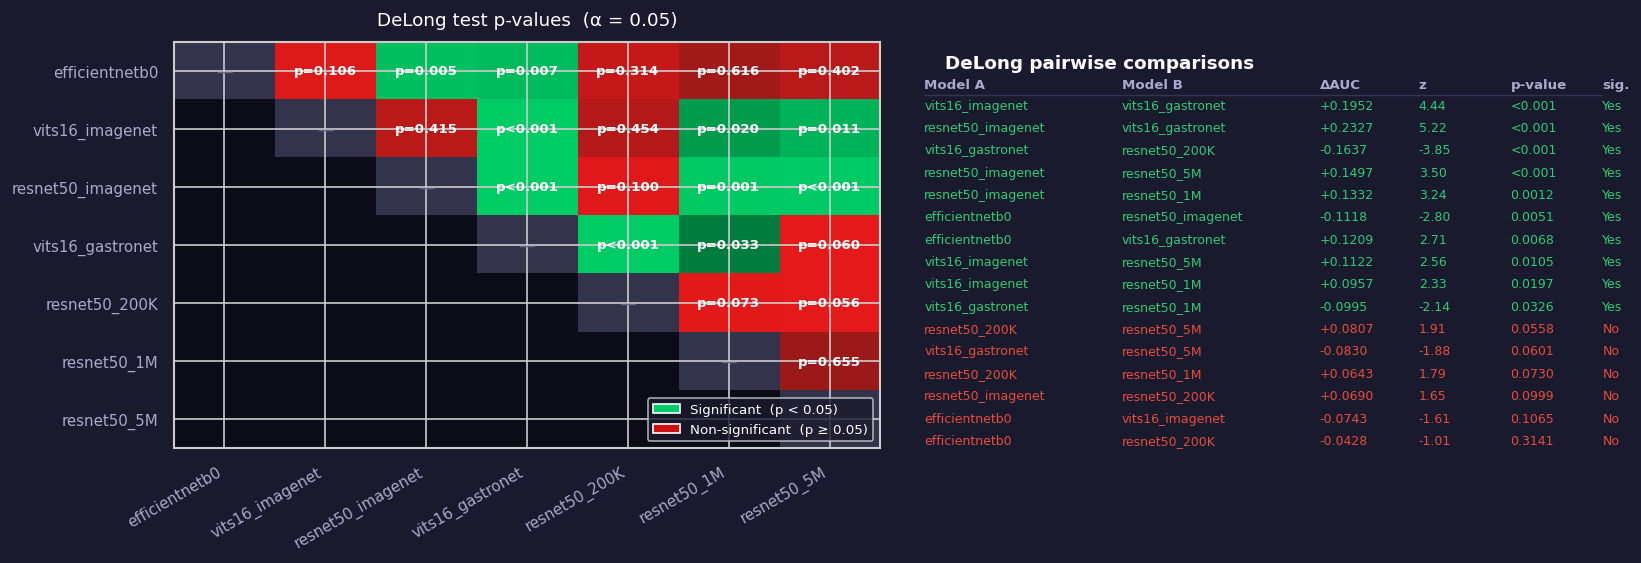

In [93]:
def run_delong_analysis(preds_dict: dict, task: str, alpha: float = 0.05) -> None:
    if len(preds_dict) < 2:
        print(f"[{task}] Need ≥ 2 models for DeLong test. Found {len(preds_dict)}.")
        return

    reference = next(iter(preds_dict))
    labels     = preds_dict[reference]["labels"]
    seed       = preds_dict[reference].get("seed", "?")
    probs_dict = {name: v["probs"] for name, v in preds_dict.items()}

    p_matrix, df_delong = delong_matrix(labels=labels, model_probs=probs_dict, alpha=alpha)

    print(f"\n{'='*60}\n{task} — DeLong pairwise test (α={alpha})"
          f"  [100% data, shared seed={seed}]\n{'='*60}")
    print(df_delong.to_string(index=False))
    n_sig = int(df_delong["significant"].sum())
    print(f"\n{n_sig}/{len(df_delong)} significant pairs (α={alpha})")

    _ = plot_delong_heatmap(p_matrix, df_delong, alpha=alpha)
    plt.show()

run_delong_analysis(ulcer_preds, "Ulcer detection", ALPHA)
run_delong_analysis(mes_preds,   "MES scoring",     ALPHA)

## 5. ROC Curves at 100% Training Data

Uses the **shared best seed** identified above (same for all models).

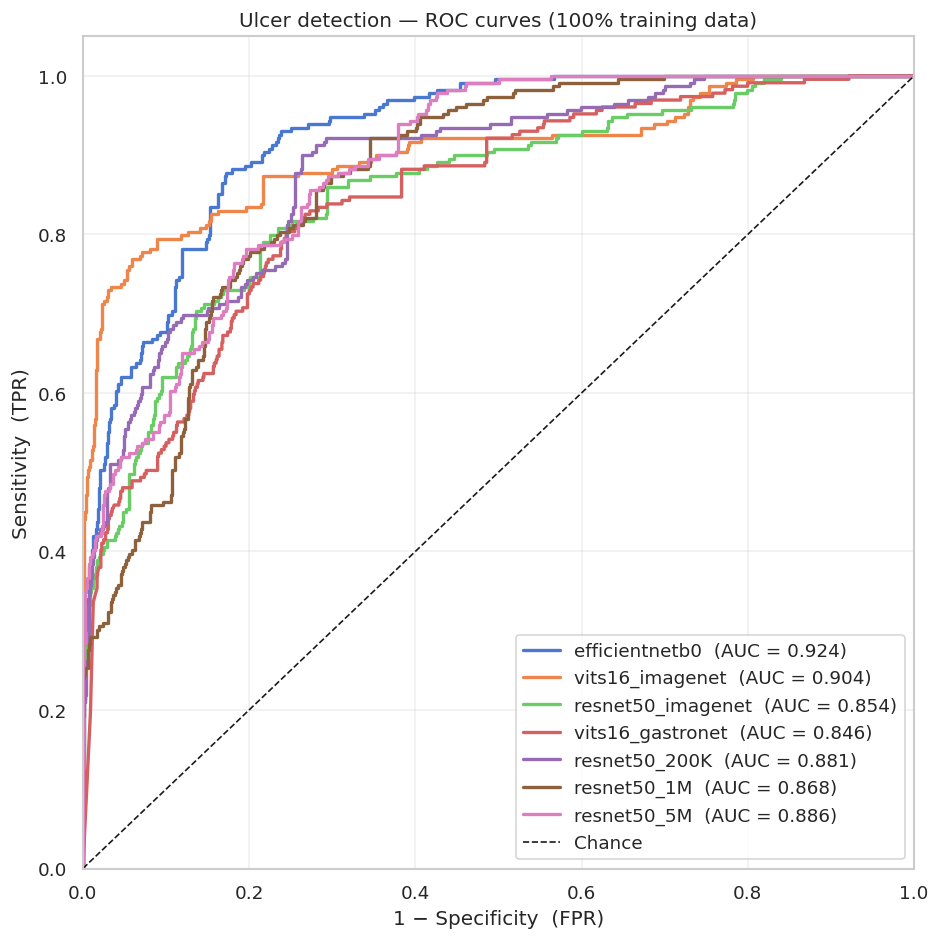

In [94]:
def plot_roc_all_models(preds_dict: dict, task: str) -> None:
    if not preds_dict:
        return

    roc_data = []
    for model_name, v in preds_dict.items():
        labels = v["labels"]
        probs  = v["probs"]
        # Binary classification: use probs directly
        # Multiclass: use max probability as simplified 1-vs-rest proxy
        if probs.ndim == 2:
            probs = probs.max(axis=1)
        try:
            fpr, tpr, _ = roc_curve(labels, probs)
            auc = roc_auc_score(labels, probs)
            roc_data.append({"name": model_name, "fpr": fpr, "tpr": tpr, "auc": auc})
        except Exception as e:
            print(f"  Could not compute ROC for {model_name}: {e}")

    if roc_data:
        _ = plot_roc_curves(roc_data, title=f"{task} — ROC curves (100% training data)")
        plt.show()

plot_roc_all_models(ulcer_preds, "Ulcer detection")

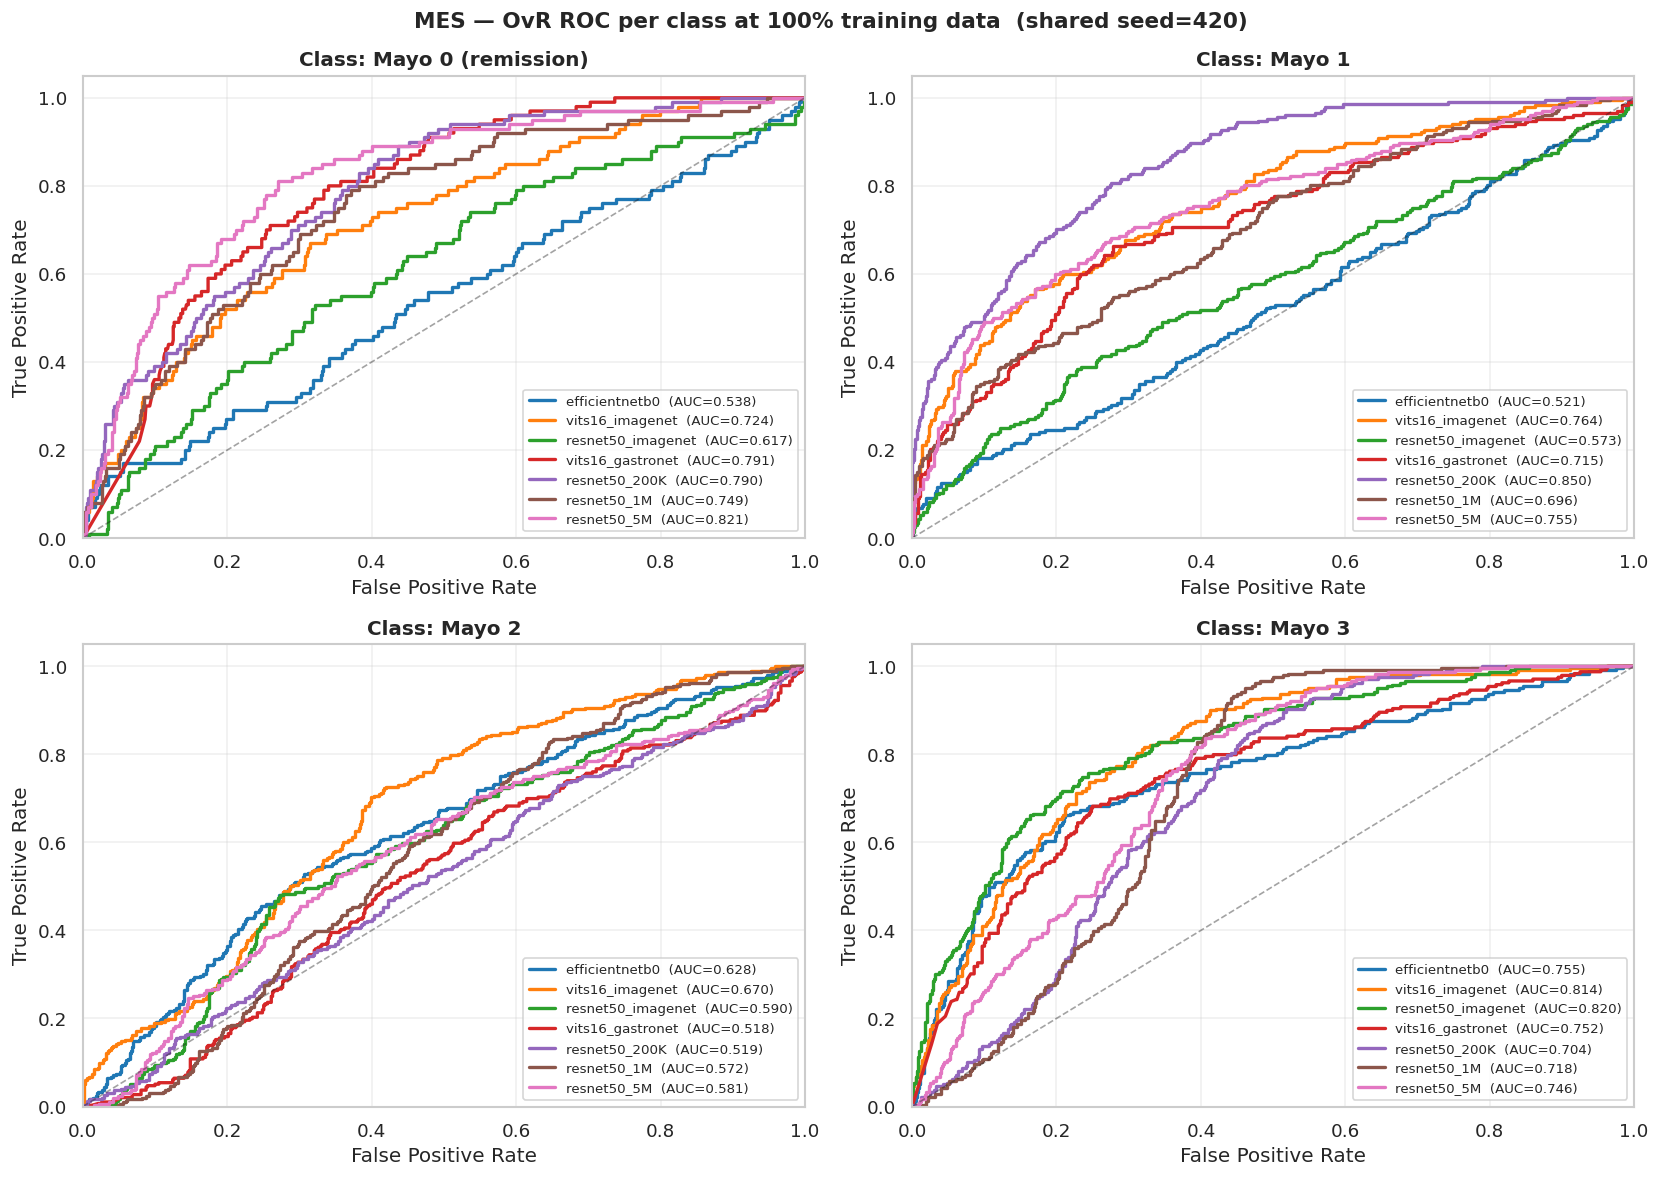

In [95]:
def plot_mes_per_class_roc(
    preds_dict: dict,
    class_names: dict | None = None,
) -> None:
    """OvR ROC per Mayo class, all models overlaid.

    Expects the dict produced by load_predictions_at_fraction (shared seed).
    Uses probs_all (full [N, 4] softmax matrix) stored on each entry.
    """
    if not preds_dict:
        print("No predictions loaded — run load_predictions_at_fraction first.")
        return

    if class_names is None:
        class_names = {0: "Mayo 0 (remission)", 1: "Mayo 1", 2: "Mayo 2", 3: "Mayo 3"}

    # Verify we have multiclass probs
    models_data = {
        name: v for name, v in preds_dict.items()
        if v.get("probs_all") is not None and v["probs_all"].ndim == 2 and v["probs_all"].shape[1] >= 4
    }
    if not models_data:
        print("No multiclass probabilities found (probs_all). "
              "Ensure MES predictions are loaded.")
        return

    # All entries share the same seed — grab it for the title
    shared_seed = next(iter(models_data.values())).get("seed", "?")

    n_classes = len(class_names)
    ncols     = 2
    nrows     = (n_classes + ncols - 1) // ncols
    colors    = plt.get_cmap("tab10").colors

    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows), squeeze=False)
    fig.suptitle(
        f"MES — OvR ROC per class at 100% training data  (shared seed={shared_seed})",
        fontsize=13, fontweight="bold",
    )

    for cls_idx, cls_name in class_names.items():
        ax = axes[cls_idx // ncols][cls_idx % ncols]
        for m_idx, (model_name, v) in enumerate(models_data.items()):
            labels        = v["labels"]
            probs         = v["probs_all"]
            binary_labels = (labels == cls_idx).astype(int)
            scores        = probs[:, cls_idx]
            try:
                fpr, tpr, _ = roc_curve(binary_labels, scores)
                auc         = roc_auc_score(binary_labels, scores)
                ax.plot(fpr, tpr,
                        label=f"{model_name}  (AUC={auc:.3f})",
                        linewidth=2, color=colors[m_idx % len(colors)])
            except Exception as e:
                print(f"  ROC error — {model_name}, class {cls_idx}: {e}")

        ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1)
        ax.set_title(f"Class: {cls_name}", fontweight="bold")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(alpha=0.3)

    for idx in range(n_classes, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.tight_layout()
    plt.show()


plot_mes_per_class_roc(mes_preds)

### 5c. Best Model — ROC + Confusion Matrix

For each task, the model with the highest AUROC at 100% training data (shared seed) is shown with:
- **ROC curve** (binary for ulcer; one OvR per class for MES)
- **Confusion matrix** — raw counts annotated, colour = row-normalised recall

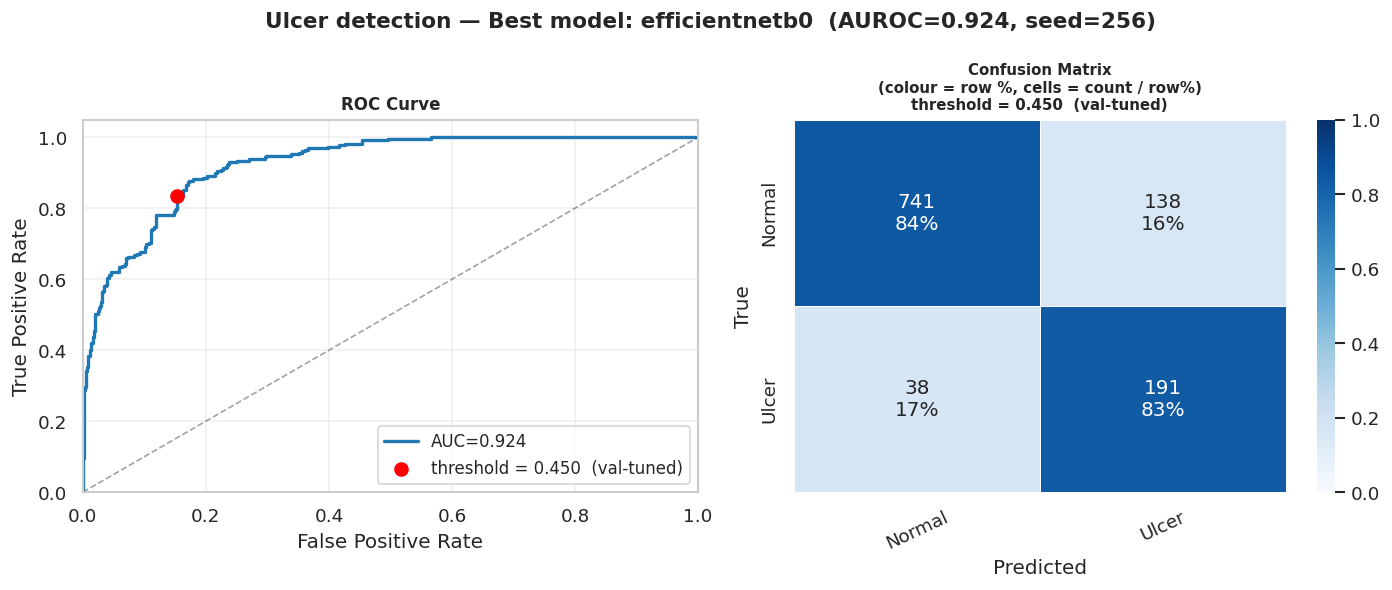

/tmp/ipykernel_20804/1153273883.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


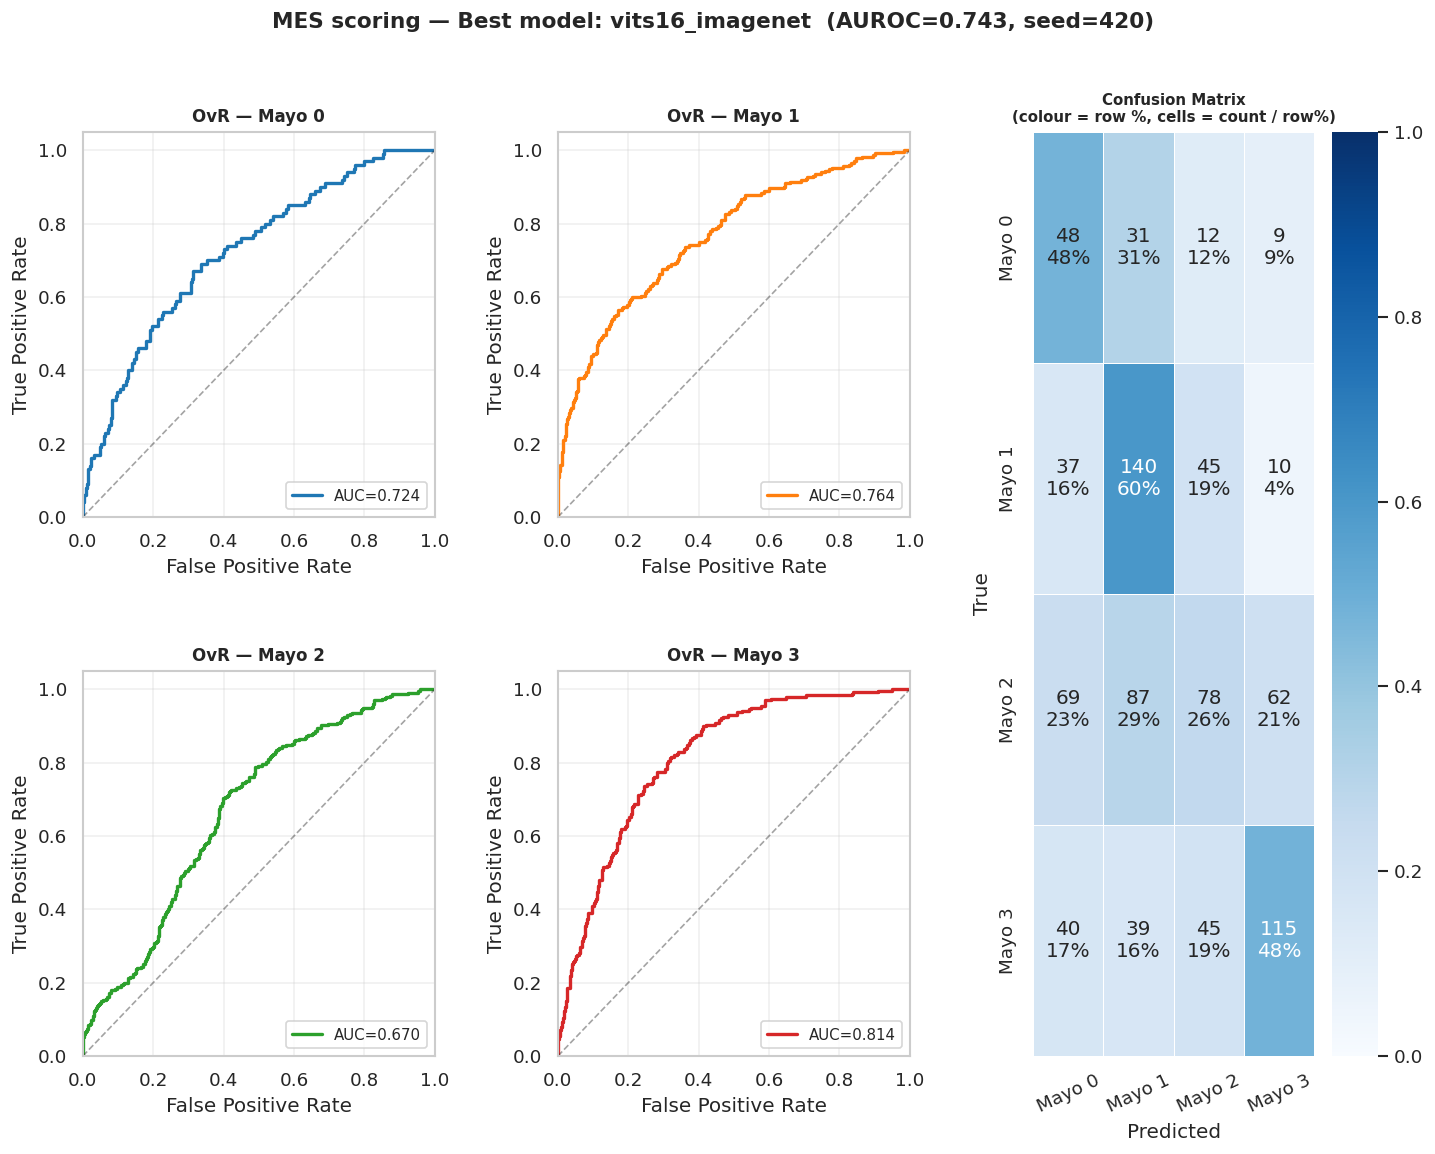

In [96]:
from sklearn.metrics import confusion_matrix


def plot_best_model_roc_cm(
    preds_dict: dict,
    task: str,
    label_names: dict | None = None,
) -> None:
    """ROC curve + confusion matrix for the best model (by AUROC) in preds_dict.

    For binary tasks (ulcer): single ROC curve, threshold tuned on val set (loaded from CSV).
    For multiclass tasks (MES): one OvR ROC per class, argmax predictions.
    CM cells show count and row-normalised percentage.
    """
    if not preds_dict:
        print(f"[{task}] No predictions loaded.")
        return

    best_name = max(preds_dict, key=lambda k: preds_dict[k]["auroc"])
    v         = preds_dict[best_name]
    labels    = v["labels"]
    probs     = v["probs"]
    probs_all = v.get("probs_all")
    auroc     = v["auroc"]
    seed      = v.get("seed", "?")
    is_multi  = probs_all is not None and probs_all.ndim == 2 and probs_all.shape[1] >= 2

    if label_names is None:
        n_cls = probs_all.shape[1] if is_multi else 2
        label_names = {i: str(i) for i in range(n_cls)}

    n_classes = len(label_names)
    colors    = plt.get_cmap("tab10").colors

    # ── Layout: ROC panel(s) on the left, CM on the right ─────────────────────
    if is_multi:
        ncols_roc = 2
        nrows_roc = (n_classes + ncols_roc - 1) // ncols_roc
        fig = plt.figure(figsize=(14, max(5 * nrows_roc, 6)))
        gs  = fig.add_gridspec(nrows_roc, ncols_roc + 1, wspace=0.35, hspace=0.4)
        roc_axes = [fig.add_subplot(gs[r, c])
                    for r in range(nrows_roc) for c in range(ncols_roc)]
        ax_cm = fig.add_subplot(gs[:, ncols_roc])
    else:
        fig, (ax_roc, ax_cm) = plt.subplots(1, 2, figsize=(12, 5))
        roc_axes = [ax_roc]

    fig.suptitle(
        f"{task} — Best model: {best_name}  (AUROC={auroc:.3f}, seed={seed})",
        fontsize=13, fontweight="bold",
    )

    # ── ROC curve(s) ──────────────────────────────────────────────────────────
    thresh_used = None
    if is_multi:
        for cls_idx, cls_name in label_names.items():
            ax = roc_axes[cls_idx]
            binary_lbl  = (labels == cls_idx).astype(int)
            scores      = probs_all[:, cls_idx]
            fpr, tpr, _ = roc_curve(binary_lbl, scores)
            auc         = roc_auc_score(binary_lbl, scores)
            ax.plot(fpr, tpr, color=colors[cls_idx % len(colors)], linewidth=2,
                    label=f"AUC={auc:.3f}")
            ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1)
            ax.set_title(f"OvR — {cls_name}", fontsize=10, fontweight="bold")
            ax.set_xlabel("False Positive Rate")
            ax.set_ylabel("True Positive Rate")
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1.05)
            ax.legend(fontsize=9, loc="lower right")
            ax.grid(alpha=0.3)
        for idx in range(n_classes, len(roc_axes)):
            roc_axes[idx].set_visible(False)
        preds = probs_all.argmax(axis=1)
    else:
        # Threshold tuned on val set during training — no leakage
        thresh_used = v.get("threshold", 0.5)
        fpr, tpr, thresholds = roc_curve(labels, probs)
        # Mark the val-tuned threshold on the curve
        thresh_idx = int(np.argmin(np.abs(thresholds - thresh_used)))
        roc_axes[0].plot(fpr, tpr, color=colors[0], linewidth=2, label=f"AUC={auroc:.3f}")
        roc_axes[0].scatter([fpr[thresh_idx]], [tpr[thresh_idx]], color="red", zorder=5,
                            s=60, label=f"threshold = {thresh_used:.3f}  (val-tuned)")
        roc_axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1)
        roc_axes[0].set_title("ROC Curve", fontsize=10, fontweight="bold")
        roc_axes[0].set_xlabel("False Positive Rate")
        roc_axes[0].set_ylabel("True Positive Rate")
        roc_axes[0].set_xlim(0, 1)
        roc_axes[0].set_ylim(0, 1.05)
        roc_axes[0].legend(fontsize=10, loc="lower right")
        roc_axes[0].grid(alpha=0.3)
        preds = (probs >= thresh_used).astype(int)

    # ── Confusion matrix ──────────────────────────────────────────────────────
    tick_labels = [label_names[i] for i in sorted(label_names)]
    cm      = confusion_matrix(labels, preds, labels=sorted(label_names))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)

    # Annotations: count on line 1, row-% on line 2
    annot = np.empty_like(cm, dtype=object)
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            annot[r, c] = f"{cm[r, c]}\n{cm_norm[r, c]:.0%}"

    cm_title = "Confusion Matrix\n(colour = row %, cells = count / row%)"
    if thresh_used is not None:
        cm_title += f"\nthreshold = {thresh_used:.3f}  (val-tuned)"

    sns.heatmap(
        cm_norm, annot=annot, fmt="", cmap="Blues",
        xticklabels=tick_labels, yticklabels=tick_labels,
        vmin=0, vmax=1, ax=ax_cm, linewidths=0.5,
    )
    ax_cm.set_title(cm_title, fontsize=9, fontweight="bold")
    ax_cm.set_xlabel("Predicted")
    ax_cm.set_ylabel("True")
    ax_cm.tick_params(axis="x", rotation=25)

    fig.tight_layout()
    plt.show()


plot_best_model_roc_cm(
    ulcer_preds,
    "Ulcer detection",
    {0: "Normal", 1: "Ulcer"},
)
plot_best_model_roc_cm(
    mes_preds,
    "MES scoring",
    {0: "Mayo 0", 1: "Mayo 1", 2: "Mayo 2", 3: "Mayo 3"},
)

## 6. Remission vs Active Disease

Collapses MES classes into the clinically relevant binary split:
**Remission** (Mayo 0) vs **Active disease** (Mayo 1–3).

Shows clinical sensitivity (detecting active disease), specificity (correctly
classifying remission), and clinical F1 for each model at 100 % training data.
Values are **averaged over seeds**.

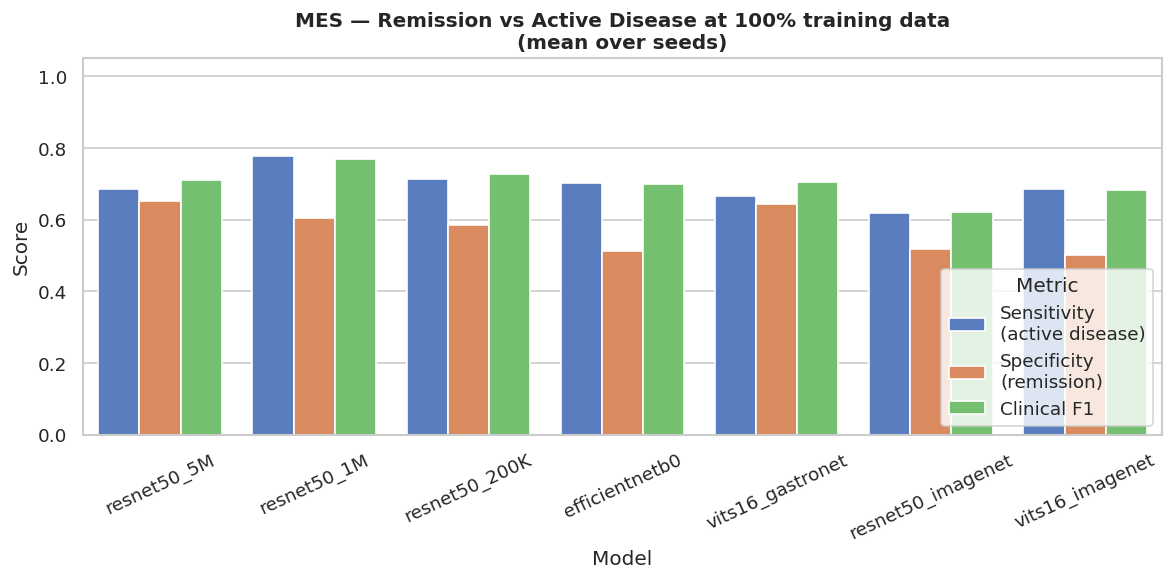

In [97]:
def plot_remission_vs_active(df: pd.DataFrame, target_pct: int = 100) -> None:
    if df is None:
        return

    # cli_sens = sensitivity for active disease (Mayo≥1 vs Mayo 0)
    # cli_spec = specificity = sensitivity for remission (Mayo 0)
    need      = ["cli_sens_mean", "cli_spec_mean", "cli_f1_mean"]
    available = [c for c in need if c in df.columns]
    if not available:
        print("No clinical columns found (cli_sens_mean, cli_spec_mean, cli_f1_mean).")
        return

    sub = df[df["pct_data"] == target_pct].copy()
    if sub.empty:
        print(f"No results at {target_pct}% training data.")
        return

    sub = sub.sort_values("auroc_mean", ascending=False)
    rename = {
        "cli_sens_mean": "Sensitivity\n(active disease)",
        "cli_spec_mean": "Specificity\n(remission)",
        "cli_f1_mean":   "Clinical F1",
    }
    melt = (
        sub[["model"] + available]
        .melt(id_vars="model", var_name="metric", value_name="value")
    )
    melt["metric"] = melt["metric"].map(rename)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=melt, x="model", y="value", hue="metric", ax=ax)
    ax.set_title(
        f"MES — Remission vs Active Disease at {target_pct}% training data\n"
        "(mean over seeds)",
        fontweight="bold",
    )
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="Metric", loc="lower right")
    fig.tight_layout()
    plt.show()


plot_remission_vs_active(df_mes)

## 7. Full Summary Export

In [98]:
def export_summary(df: pd.DataFrame, task: str, out_dir: Path) -> None:
    if df is None:
        return
    out_dir.mkdir(parents=True, exist_ok=True)

    # Best model per fraction
    best_per_fraction = (
        df.loc[df.groupby("pct_data")["auroc_mean"].idxmax()]
        [["pct_data", "model", "auroc_mean", "auroc_std", "f1_mean", "f1_std"]]
        .sort_values("pct_data")
    )
    out_path = out_dir / f"{task}_best_per_fraction.csv"
    best_per_fraction.to_csv(out_path, index=False)
    print(f"[{task}] Exported: {out_path}")
    display(best_per_fraction.round(4))

export_summary(df_ulcer, "ulcer", ROOT / "results/ulcer/data_efficiency")
export_summary(df_mes,   "mes",   ROOT / "results/mes/data_efficiency")

[ulcer] Exported: ../results/ulcer/data_efficiency/ulcer_best_per_fraction.csv


,pct_data,model,auroc_mean,auroc_std,f1_mean,f1_std
15,10,resnet50_5M,0.7928,0.0700,0.4727,0.0531
1,25,efficientnetb0,0.8833,0.0434,0.6105,0.0804
2,50,efficientnetb0,0.9170,0.0222,0.6770,0.0289
3,75,efficientnetb0,0.9253,0.0091,0.6862,0.0513
4,100,efficientnetb0,0.9298,0.0102,0.7040,0.0411


[mes] Exported: ../results/mes/data_efficiency/mes_best_per_fraction.csv


,pct_data,model,auroc_mean,auroc_std,f1_mean,f1_std
15,10,resnet50_5M,0.6840,0.0575,0.3248,0.1099
16,25,resnet50_5M,0.6902,0.0612,0.3563,0.0579
12,50,resnet50_200K,0.7200,0.0143,0.4187,0.0148
23,75,resnet50_imagenet,0.6892,0.0246,0.4048,0.0433
19,100,resnet50_5M,0.6912,0.0236,0.3635,0.0643
